EXPERIMENT 05 - TASK 02
Bagging, Random Forest and Voting
Name    : R. Karthik
Roll No : 25EU02904

Sonar Dataset Shape:
(208, 61)

First Five Rows:
      F_1     F_2     F_3     F_4     F_5     F_6     F_7     F_8     F_9  \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

     F_10  ...    F_52    F_53    F_54    F_55    F_56    F_57    F_58  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.

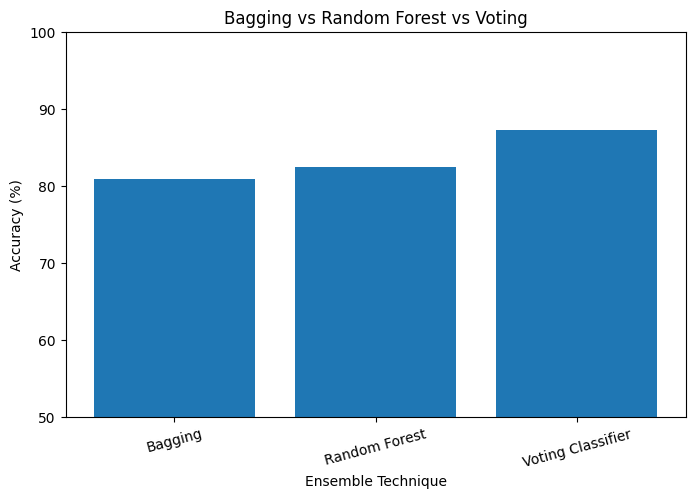


Best Ensemble Model:
Voting Classifier
Accuracy: 87.30%

TASK 02 COMPLETED SUCCESSFULLY
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 05 - TASK 02
# Ensemble Learning: Bagging, Random Forest and Voting
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    VotingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("EXPERIMENT 05 - TASK 02")
print("Bagging, Random Forest and Voting")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)


# ============================================================
# 1. LOAD SONAR DATASET
# ============================================================

sonar_url = (
    "https://raw.githubusercontent.com/jbrownlee/"
    "Datasets/master/sonar.csv"
)

sonar_features = [
    f"F_{i}"
    for i in range(1, 61)
]

sonar_columns = sonar_features + ["Class"]

sonar_df = pd.read_csv(
    sonar_url,
    header=None,
    names=sonar_columns
)

print("\nSonar Dataset Shape:")
print(sonar_df.shape)

print("\nFirst Five Rows:")
print(sonar_df.head())


# ============================================================
# 2. ENCODE TARGET
# ============================================================

sonar_df["Class_numeric"] = sonar_df["Class"].map({
    "M": 1,
    "R": 0
})

X = sonar_df[sonar_features]

y = sonar_df["Class_numeric"]


# ============================================================
# 3. STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)


# ============================================================
# 4. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


# ============================================================
# 5. BAGGING CLASSIFIER
# ============================================================

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(
    X_train,
    y_train
)

bagging_predictions = bagging_model.predict(
    X_test
)

bagging_accuracy = accuracy_score(
    y_test,
    bagging_predictions
)

print("\nBagging Classifier Accuracy:")
print(f"{bagging_accuracy * 100:.2f}%")


# ============================================================
# 6. RANDOM FOREST CLASSIFIER
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("\nRandom Forest Accuracy:")
print(f"{rf_accuracy * 100:.2f}%")


# ============================================================
# 7. VOTING CLASSIFIER
# ============================================================

estimators = [
    (
        "lr",
        LogisticRegression(
            max_iter=500,
            random_state=42
        )
    ),
    (
        "dt",
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        )
    ),
    (
        "svc",
        SVC(
            probability=True,
            random_state=42
        )
    )
]

voting_model = VotingClassifier(
    estimators=estimators,
    voting="soft",
    n_jobs=-1
)

voting_model.fit(
    X_train,
    y_train
)

voting_predictions = voting_model.predict(
    X_test
)

voting_accuracy = accuracy_score(
    y_test,
    voting_predictions
)

print("\nVoting Classifier Accuracy:")
print(f"{voting_accuracy * 100:.2f}%")


# ============================================================
# 8. PERFORMANCE COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Ensemble Technique": [
        "Bagging",
        "Random Forest",
        "Voting Classifier"
    ],
    "Accuracy (%)": [
        bagging_accuracy * 100,
        rf_accuracy * 100,
        voting_accuracy * 100
    ]
})

print("\nPerformance Comparison:")
print(
    comparison.to_string(index=False)
)


# ============================================================
# 9. BAR GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Ensemble Technique"],
    comparison["Accuracy (%)"]
)

plt.xlabel("Ensemble Technique")

plt.ylabel("Accuracy (%)")

plt.title(
    "Bagging vs Random Forest vs Voting"
)

plt.ylim(50, 100)

plt.xticks(rotation=15)

plt.show()


# ============================================================
# 10. BEST MODEL
# ============================================================

best_model = comparison.loc[
    comparison["Accuracy (%)"].idxmax()
]

print("\nBest Ensemble Model:")
print(
    best_model["Ensemble Technique"]
)

print(
    f"Accuracy: {best_model['Accuracy (%)']:.2f}%"
)


# ============================================================
# CONCLUSION
# ============================================================

print("\n" + "=" * 60)
print("TASK 02 COMPLETED SUCCESSFULLY")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)